In [1]:
import sys
from pathlib import Path
sys.path.append("/home/marc/Code/boa")

import os
os.environ["PROJECT_ROOT"] = "/home/marc/Code/boa"

import hydra
from hydra import initialize, compose
from omegaconf import OmegaConf
import matplotlib.pyplot as plt
import torch

from dotenv import load_dotenv
load_dotenv()

# Monkey patch the HydraConfig.get method to avoid the error
from hydra.core.hydra_config import HydraConfig

# Store the original method before patching
_original_get = HydraConfig.get

@classmethod 
def patched_get(cls):
    try:
        instance = cls.instance()
        if instance.cfg is None:
            raise ValueError("HydraConfig was not set")
        return instance.cfg.hydra
    except ValueError:
        # Return a minimal mock config when HydraConfig is not set
        from omegaconf import DictConfig
        mock_config = DictConfig({
            "job": {
                "override_dirname": "",
                "num": "0"
            },
            "runtime": {
                "output_dir": "/tmp/hydra_fallback"
            },
            "sweep": {
                "dir": "/tmp/hydra_sweep"
            }
        })
        return mock_config

# Apply the monkey patch
HydraConfig.get = patched_get

# Import and register the custom resolvers from your project
from boa.utils.omegaconf_resolvers import *

from boa.model.module import ChgLightningModule

run_path = Path("/home/marc/media/cluster_scratch/boa/models/train/runs/437_qm9_small_qm9_vasp_small__seed-2")
best_ckpt = (run_path / "best_model_path.txt").read_text().strip()
model_path = run_path / best_ckpt
config_path = run_path / "config.yaml"

# cfg = OmegaConf.load(config_path)

with initialize(config_path="../configs", version_base="1.1"):
    cfg = compose(config_name="train.yaml", overrides=["data=qm9_vasp_small", "data.basis_info.basis=def2-svp"]) # def2-svp

# First instantiate datamodule to get metadata
datamodule = hydra.utils.instantiate(cfg.data.datamodule, _recursive_=False)
datamodule.setup("fit")  # This creates the metadata
metadata = datamodule.metadata

print(f"Metadata: {metadata}")

# Now instantiate model with proper metadata
model = hydra.utils.instantiate(cfg.model, train=cfg, _recursive_=False, metadata=metadata)
# model = ChgLightningModule.load_from_checkpoint(model_path, map_location="cpu")

/home/marc/Code/boa/.venv/lib/python3.11/site-packages/IPython/core/async_helpers.py:128: UserWarning: 
'hydra/launcher/basic' is validated against ConfigStore schema with the same name.
This behavior is deprecated in Hydra 1.1 and will be removed in Hydra 1.2.
See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/automatic_schema_matching for migration instructions.
  coro.send(None)


Metadata: {'target_mean': 0.07815587520599365, 'target_var': 0.10440607368946075, 'avg_num_neighbors': 8, 'unique_atom_types': [1, 6, 7, 8, 9]}
Unique atom types: [1 6 7 8 9]
Using radial correction for GTOs.
Using radial correction for GTOs.
Using radial correction for GTOs.
Using radial correction for GTOs.
Using radial correction for GTOs.


/home/marc/Code/boa/boa/model/module.py:124: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(gto.contraction, dtype=torch.int64),


BOA(
  (boa_stack): BoaBlockStack(
    (blocks): ModuleList(
      (0-3): 4 x BoaBlock(
        (linear0): StableLinearNodeOperator(
          (stable_linear_node_operators): ModuleDict(
            (1): StableLinearNodeOperatorAtom(
              (linear1): Linear(4x0e+1x1o -> 4x0e+1x1o | 17 weights)
            )
            (6): StableLinearNodeOperatorAtom(
              (linear1): Linear(7x0e+4x1o+1x2e -> 7x0e+4x1o+1x2e | 66 weights)
            )
            (7): StableLinearNodeOperatorAtom(
              (linear1): Linear(7x0e+4x1o+1x2e -> 7x0e+4x1o+1x2e | 66 weights)
            )
            (8): StableLinearNodeOperatorAtom(
              (linear1): Linear(7x0e+4x1o+1x2e -> 7x0e+4x1o+1x2e | 66 weights)
            )
            (9): StableLinearNodeOperatorAtom(
              (linear1): Linear(7x0e+4x1o+1x2e -> 7x0e+4x1o+1x2e | 66 weights)
            )
          )
        )
        (linear1): StableLinearNodeOperator(
          (stable_linear_node_operators): ModuleDict(
  

In [8]:
train_set = datamodule.train_dataset
val_set = datamodule.val_dataset
sample = train_set[862]
print(sample)
# Phenol ids: [862, 1055, 1127, 1271, 1282]

OFData(
  pos=[13, 3],
  atomic_numbers=[13],
  coeffs=[210],
  atom_ind=[13],
  n_basis_per_atom=[13],
  atom_ptr=[13],
  basis_function_ind=[210],
  coeff_ind_to_node_ind=[210],
  dual_basis_integrals=[210],
  irreps_per_atom=[13],
  representations={
    pos=Representation.NONE,
    atomic_numbers=Representation.NONE,
    coeffs=Representation.VECTOR,
    ground_state_coeffs=Representation.VECTOR,
    gradient_label=Representation.GRADIENT,
    energy_label=Representation.SCALAR,
    has_energy_label=Representation.NONE,
    atom_ind=Representation.NONE,
    n_basis_per_atom=Representation.NONE,
    atom_ptr=Representation.NONE,
    basis_function_ind=Representation.NONE,
    coeff_ind_to_node_ind=Representation.NONE,
    dual_basis_integrals=Representation.DUAL_VECTOR,
    mol_id=Representation.NONE,
    scf_iteration=Representation.NONE,
    irreps_per_atom=Representation.NONE,
    representations=Representation.NONE,
    n_probe=Representation.NONE,
    probe_coords=Representatio

In [10]:
import pyvista as pv
from mldft.utils.visualize_3d import get_sticks_mesh_dict
from mldft.utils.molecules import build_molecule_ofdata

# Switch to static backend for better sphere rendering in notebooks
# pv.set_jupyter_backend('static')  # Use static backend for notebooks
# pv.set_jupyter_backend('html')    # Interactive with panel
# pv.set_jupyter_backend('trame')    # Interactive with trame
# pv.set_jupyter_backend('pythreejs') # Interactive with pythreejs

mol = build_molecule_ofdata(sample)

pl = pv.Plotter(notebook=True)
pl.add_mesh(**get_sticks_mesh_dict(mol))
pl.show()

Widget(value='<iframe src="http://localhost:42153/index.html?ui=P_0x7f9184325a10_0&reconnect=auto" class="pyvi…

ERROR:root:Out of space for intersections!
ERROR:root:Out of space for intersections!
ERROR:root:Out of space for intersections!
ERROR:root:Out of space for intersections!
ERROR:root:Out of space for intersections!
ERROR:root:Out of space for intersections!
ERROR:root:Out of space for intersections!
ERROR:root:Out of space for intersections!
ERROR:root:Out of space for intersections!
ERROR:root:Out of space for intersections!
ERROR:root:Out of space for intersections!
ERROR:root:Out of space for intersections!
ERROR:root:Out of space for intersections!
ERROR:root:Out of space for intersections!
ERROR:root:Out of space for intersections!
ERROR:root:Out of space for intersections!
ERROR:root:Out of space for intersections!
ERROR:root:Out of space for intersections!
ERROR:root:Out of space for intersections!
ERROR:root:Out of space for intersections!
ERROR:root:Out of space for intersections!
ERROR:root:Out of space for intersections!
ERROR:root:Out of space for intersections!
ERROR:root:

In [11]:
model.gto_dict

ModuleDict(
  (1): GTOs(Lmax=1, n_orbitals=5, n_contracted=5.0, outdim=7)
  (6): GTOs(Lmax=2, n_orbitals=12, n_contracted=12.0, outdim=24)
  (7): GTOs(Lmax=2, n_orbitals=12, n_contracted=12.0, outdim=24)
  (8): GTOs(Lmax=2, n_orbitals=12, n_contracted=12.0, outdim=24)
  (9): GTOs(Lmax=2, n_orbitals=12, n_contracted=12.0, outdim=24)
)

In [12]:
import numpy as np
from scipy.spatial.distance import cdist

def compute_gaussian_product_peaks(sample, gto_dict, min_distance_threshold=0.1):
    """
    Compute the peaks of Gaussian products for neighboring atoms within cutoff.
    
    When two Gaussians exp(-α₁|r-R₁|²) and exp(-α₂|r-R₂|²) are multiplied,
    the product is a Gaussian with peak at: R_peak = (α₁R₁ + α₂R₂)/(α₁ + α₂)
    
    Args:
        sample: Molecule data containing positions, atomic numbers, edge_index
        gto_dict: Dictionary of GTOs for each atom type
        min_distance_threshold: Minimum distance between peaks to avoid duplicates
    
    Returns:
        peak_coords: Tensor of shape (N_peaks, 3) with peak coordinates
        peak_info: List of dictionaries with metadata for each peak
    """
    
    # Get molecular information
    atomic_numbers = sample.atomic_numbers
    positions = sample.pos
    edge_index = sample.edge_index
    
    # Store all peaks and their metadata
    all_peaks = []
    peak_info = []
    
    # Process each edge (atom pair)
    for edge_idx in range(edge_index.shape[1]):
        atom_i_idx = edge_index[0, edge_idx].item()
        atom_j_idx = edge_index[1, edge_idx].item()
        
        # Skip self-loops for now (we could include them for completeness)
        if atom_i_idx == atom_j_idx:
            continue
            
        atom_i_type = atomic_numbers[atom_i_idx].item()
        atom_j_type = atomic_numbers[atom_j_idx].item()
        
        pos_i = positions[atom_i_idx]
        pos_j = positions[atom_j_idx]
        
        # Check if atoms are within cutoff distance
        distance = torch.norm(pos_i - pos_j).item()
        
        # Get GTOs for both atoms
        gto_i = gto_dict[str(atom_i_type)]
        gto_j = gto_dict[str(atom_j_type)]
        
        if distance > max(gto_i.cutoff, gto_j.cutoff):
            continue
            
        # Get exponents for both atoms
        expos_i = gto_i.expos
        expos_j = gto_j.expos
        
        # Compute peaks for all combinations of basis functions
        for k, exp_i in enumerate(expos_i):
            for l, exp_j in enumerate(expos_j):
                # Peak of product of two Gaussians: weighted average of centers
                alpha_i = exp_i.item()
                alpha_j = exp_j.item()
                
                # Peak position: (α₁R₁ + α₂R₂)/(α₁ + α₂)
                peak_pos = (alpha_i * pos_i + alpha_j * pos_j) / (alpha_i + alpha_j)
                
                # Store peak information
                peak_info_dict = {
                    'atom_i_idx': atom_i_idx,
                    'atom_j_idx': atom_j_idx,
                    'atom_i_type': atom_i_type,
                    'atom_j_type': atom_j_type,
                    'atom_i_pos': pos_i.clone(),
                    'atom_j_pos': pos_j.clone(),
                    'basis_i_idx': k,
                    'basis_j_idx': l,
                    'exp_i': alpha_i,
                    'exp_j': alpha_j,
                    'distance': distance,
                    'peak_pos': peak_pos.clone()
                }
                
                all_peaks.append(peak_pos)
                peak_info.append(peak_info_dict)
    
    if not all_peaks:
        return torch.empty(0, 3), []
    
    # Convert to tensor
    peak_coords = torch.stack(all_peaks)
    
    # Remove duplicates that are too close together
    if min_distance_threshold > 0:
        unique_peaks = []
        unique_info = []
        
        for i, (peak, info) in enumerate(zip(peak_coords, peak_info)):
            is_duplicate = False
            for existing_peak in unique_peaks:
                if torch.norm(peak - existing_peak) < min_distance_threshold:
                    is_duplicate = True
                    break
            
            if not is_duplicate:
                unique_peaks.append(peak)
                unique_info.append(info)
        
        if unique_peaks:
            peak_coords = torch.stack(unique_peaks)
            peak_info = unique_info
        else:
            peak_coords = torch.empty(0, 3)
            peak_info = []
    
    return peak_coords, peak_info

# Test the function
peaks, peak_info = compute_gaussian_product_peaks(sample, model.gto_dict, min_distance_threshold=0)
print(f"Found {len(peaks)} unique Gaussian product peaks")
print(f"Peak coordinates shape: {peaks.shape}")

Found 7834 unique Gaussian product peaks
Peak coordinates shape: torch.Size([7834, 3])


In [13]:
def get_atoms_only_mesh_dict(sample, atom_radius=0.2, resolution=20):
    """
    Create an atoms-only representation for a molecule (no bonds).
    
    Args:
        sample: Molecule data containing positions and atomic numbers
        atom_radius: The radius of the spheres representing atoms
        resolution: The resolution of the spheres
        
    Returns:
        A dictionary with keyword arguments to pass to pyvista.Plotter.add_mesh
    """
    # Color mapping for atoms
    ATOM_COLORS = {
        1: "#eeeeee",   # H - white
        6: "#555555",   # C - gray
        7: "#8f8fff",   # N - blue
        8: "#f00000",   # O - red
        9: "#ffff00",   # F - yellow
        15: "#ffa500",  # P - orange
        16: "#ffc832",  # S - yellow
        19: "#42f4ee",  # K - cyan
        0: "#3f3f3f",   # Unknown - dark gray
    }
    
    # Get positions and atomic numbers directly from sample
    positions = sample.pos  # Already in Bohr
    atomic_numbers = sample.atomic_numbers
    
    mesh_elements = []
    
    # Create spheres for atoms only
    for i, (pos, atomic_num) in enumerate(zip(positions, atomic_numbers)):
        atomic_num = atomic_num.item()
        color_id = list(ATOM_COLORS.keys()).index(atomic_num) if atomic_num in ATOM_COLORS else list(ATOM_COLORS.keys()).index(0)
        
        sphere = pv.Sphere(
            center=pos.numpy(),
            radius=atom_radius,
            phi_resolution=resolution,
            theta_resolution=resolution,
        )
        sphere["color_ids"] = np.ones(sphere.n_cells) * color_id
        mesh_elements.append(sphere)
    
    merged_mesh = pv.MultiBlock(mesh_elements).combine().extract_surface()
    add_mesh_kwargs = dict(
        mesh=merged_mesh,
        smooth_shading=True,
        diffuse=0.5,
        specular=0.5,
        ambient=0.5,
        clim=(0, len(ATOM_COLORS)-1),
        cmap=list(ATOM_COLORS.values()),
        show_scalar_bar=False,
    )
    return add_mesh_kwargs

def find_isosurface_value(
    cube_array: np.ndarray, quantile: float | np.ndarray = 0.9, p: int = 2
) -> float | np.ndarray:
    """Find an isosurface value for a cube array, such that the isosurface contains a given
    fraction of the total mass. The mass is computed as the sum of the absolute values of the cube
    array raised to the power p.

    Args:
        cube_array: The cube array.
        quantile: The fraction (or array of fractions) of the total mass to be contained in the isosurface.
        p: The power to raise the cube array to. Use p=1 for electron density and p=2 for orbitals.

    Returns:
        The isosurface value.
    """
    cube_array = np.abs(cube_array).flatten()
    mass = cube_array**p
    total_mass = mass.sum()
    mass_sorted = np.sort(mass)[::-1]
    ind = np.searchsorted(np.cumsum(mass_sorted), total_mass * quantile)
    isosurface_value = mass_sorted[ind] ** (1 / p)

    return isosurface_value

In [15]:
# Find indices of H-H (hydrogen-hydrogen) connections
hh_indices = []
for i, info in enumerate(peak_info):
    atom_i_type = info['atom_i_type']
    atom_j_type = info['atom_j_type']
    
    # Check if both atoms are hydrogen (atomic number 1)
    if atom_i_type == 1 and atom_j_type == 1:
        hh_indices.append(i)

print(f"Found {len(hh_indices)} H-H connections out of {len(peak_info)} total peaks")
print(f"H-H connection indices: {hh_indices[:20]}...")  # Show first 20
print(f"Percentage of H-H connections: {len(hh_indices)/len(peak_info)*100:.1f}%")

# Also find other connection types for comparison
cc_indices = []  # Carbon-Carbon
ch_indices = []  # Carbon-Hydrogen

for i, info in enumerate(peak_info):
    atom_i_type = info['atom_i_type']
    atom_j_type = info['atom_j_type']
    
    # Carbon-Carbon connections
    if atom_i_type == 6 and atom_j_type == 6:
        cc_indices.append(i)
    
    # Carbon-Hydrogen connections (either C-H or H-C)
    if (atom_i_type == 6 and atom_j_type == 1) or (atom_i_type == 1 and atom_j_type == 6):
        ch_indices.append(i)

Found 250 H-H connections out of 7834 total peaks
H-H connection indices: [6384, 6385, 6386, 6387, 6388, 6389, 6390, 6391, 6392, 6393, 6394, 6395, 6396, 6397, 6398, 6399, 6400, 6401, 6402, 6403]...
Percentage of H-H connections: 3.2%


In [16]:
def print_peak_info(selected_peak_info):
    print(f"Selected peak between atoms {selected_peak_info['atom_i_idx']} and {selected_peak_info['atom_j_idx']}")
    print(f"Atom types: {selected_peak_info['atom_i_type']} and {selected_peak_info['atom_j_type']}")
    print(f"Basis functions: {selected_peak_info['basis_i_idx']} and {selected_peak_info['basis_j_idx']}")
    print(f"Peak position: {selected_peak_info['peak_pos']}")

    # Get GTO info for the specific basis functions
    gto_i = model.gto_dict[str(selected_peak_info['atom_i_type'])]
    gto_j = model.gto_dict[str(selected_peak_info['atom_j_type'])]
    L_i = gto_i.Ls[selected_peak_info['basis_i_idx']].item()
    L_j = gto_j.Ls[selected_peak_info['basis_j_idx']].item()
    print(f"Angular momentum: L_i = {L_i}, L_j = {L_j}")
    print(f"Number of spherical harmonics: (2*{L_i}+1) = {2*L_i+1}, (2*{L_j}+1) = {2*L_j+1}")

In [17]:
selected_peak_info = peak_info[6384]  # Pick first peak
selected_peak_pos = selected_peak_info['peak_pos']
print_peak_info(selected_peak_info)

def plot_mol_and_connections(plotter):
    plotter.enable_shadows()
    plotter.enable_anti_aliasing()
    
    # Add atoms with slight transparency to allow volume rendering through them
    atom_mesh_kwargs = get_atoms_only_mesh_dict(sample, atom_radius=0.2, resolution=40)
    plotter.add_mesh(**atom_mesh_kwargs)  # Slight transparency
    
    # Add peak points
    # point_size=40
    plotter.add_points(peaks.numpy(), color='#60bc9cff', point_size=40, render_points_as_spheres=True, metallic=0., roughness=0.4, opacity=0.999)
    plotter.add_points(selected_peak_info['peak_pos'].numpy().reshape(1, -1), color='#f39c12', point_size=40, render_points_as_spheres=True, metallic=0., roughness=0.2, opacity=0.999)
    return plotter

Selected peak between atoms 8 and 7
Atom types: 1 and 1
Basis functions: 0 and 0
Peak position: tensor([2.1483, 6.6897, 2.7320])
Angular momentum: L_i = 0, L_j = 0
Number of spherical harmonics: (2*0+1) = 1, (2*0+1) = 1


In [18]:
def compute_gaussian_product_3d(peak_info_single, gto_dict, grid_resolution=80, extent=3.0, m1=0, m2=0):
    """
    Compute the 3D Gaussian product function on a grid around the peak using full GTOs.
    
    Args:
        peak_info_single: Single peak info dictionary
        gto_dict: Dictionary of GTOs for each atom type
        grid_resolution: Number of grid points in each dimension (increased for smoother rendering)
        extent: Half-size of the grid in Bohr
        use_all_orbitals: If True, sum over all orbitals for each radial function.
                         If False, use the maximum component (for visualization)
        
    Returns:
        grid: PyVista structured grid with Gaussian product values
    """
    # Extract information
    pos_i = peak_info_single['atom_i_pos']
    pos_j = peak_info_single['atom_j_pos']
    atom_i_type = peak_info_single['atom_i_type']
    atom_j_type = peak_info_single['atom_j_type']
    basis_i_idx = peak_info_single['basis_i_idx']
    basis_j_idx = peak_info_single['basis_j_idx']
    peak_pos = peak_info_single['peak_pos']
    
    # Get the GTO objects for both atoms
    gto_i = gto_dict[str(atom_i_type)]
    gto_j = gto_dict[str(atom_j_type)]
    
    # Create 3D grid centered around the peak
    x = torch.linspace(peak_pos[0] - extent, peak_pos[0] + extent, grid_resolution)
    y = torch.linspace(peak_pos[1] - extent, peak_pos[1] + extent, grid_resolution)
    z = torch.linspace(peak_pos[2] - extent, peak_pos[2] + extent, grid_resolution)
    
    # Create meshgrid
    X, Y, Z = torch.meshgrid(x, y, z, indexing='ij')
    grid_points = torch.stack([X.flatten(), Y.flatten(), Z.flatten()], dim=1)
    
    # Compute displacement vectors from each atom to all grid points
    vecs_i = grid_points - pos_i.unsqueeze(0)  # (N_grid, 3)
    vecs_j = grid_points - pos_j.unsqueeze(0)  # (N_grid, 3)
    
    # Convert to Angstrom for GTO computation (GTOs expect Angstrom input)
    from scdp.common.constants import bohr2ang
    vecs_i_ang = vecs_i / bohr2ang
    vecs_j_ang = vecs_j / bohr2ang
    
    # Compute GTOs at all grid points
    with torch.no_grad():  # Disable gradient computation to avoid issues
        gto_values_i = gto_i.compute(vecs_i_ang)  # (N_grid, n_orbitals_i)
        gto_values_j = gto_j.compute(vecs_j_ang)  # (N_grid, n_orbitals_j)
    
    # Extract the specific basis function values
    # Find which columns correspond to our basis functions
    # Each radial function contributes (2*L+1) spherical harmonics
    start_idx_i = 0
    for l_idx in range(basis_i_idx):
        start_idx_i += 2 * gto_i.Ls[l_idx] + 1
    idx_i = start_idx_i + m1
    
    start_idx_j = 0
    for l_idx in range(basis_j_idx):
        start_idx_j += 2 * gto_j.Ls[l_idx] + 1
    idx_j = start_idx_j + m2  # Fixed: was start_idx_i + m2
    print(f"Selected GTOs: {idx_i}, {idx_j}")
    # Get orbital components for the specific radial functions
    gto_i_selected = gto_values_i[:, idx_i]  # (N_grid, 2*L_i+1)
    gto_j_selected = gto_values_j[:, idx_j]  # (N_grid, 2*L_j+1)

    # Compute the product
    product = gto_i_selected * gto_j_selected
    
    # Reshape back to 3D
    product_3d = product.reshape(grid_resolution, grid_resolution, grid_resolution)
    
    # Create PyVista structured grid
    grid = pv.StructuredGrid(X.numpy(), Y.numpy(), Z.numpy())
    grid["gaussian_product"] = product_3d.detach().numpy().flatten()
    
    return grid

# Use higher resolution for smoother rendering
gaussian_grid = compute_gaussian_product_3d(selected_peak_info, model.gto_dict, grid_resolution=80, extent=3.0, m1=2, m2=2)
gaussian_values = gaussian_grid["gaussian_product"]
print(gaussian_values.min(), gaussian_values.max(), gaussian_values.mean())

Selected GTOs: 2, 2
1.677339e-39 0.029763183 0.00012449878


In [19]:
# Debug: Let's check the GTO values and distances
print(f"Peak info: atoms {selected_peak_info['atom_i_idx']}-{selected_peak_info['atom_j_idx']}, types {selected_peak_info['atom_i_type']}-{selected_peak_info['atom_j_type']}")
print(f"Atom positions: {selected_peak_info['atom_i_pos']} and {selected_peak_info['atom_j_pos']}")
print(f"Distance between atoms: {selected_peak_info['distance']:.4f} Bohr")
print(f"Peak position: {selected_peak_info['peak_pos']}")

# Check the GTO shapes and values at the peak
gto_i = model.gto_dict[str(selected_peak_info['atom_i_type'])]
gto_j = model.gto_dict[str(selected_peak_info['atom_j_type'])]
print(f"GTO_i exponents: {gto_i.expos}")
print(f"GTO_j exponents: {gto_j.expos}")
print(f"GTO_i Ls: {gto_i.Ls}")
print(f"GTO_j Ls: {gto_j.Ls}")

# Test GTO computation at the peak position
from scdp.common.constants import bohr2ang
peak_pos = selected_peak_info['peak_pos']
vec_i_peak = (peak_pos - selected_peak_info['atom_i_pos']).unsqueeze(0) / bohr2ang
vec_j_peak = (peak_pos - selected_peak_info['atom_j_pos']).unsqueeze(0) / bohr2ang

with torch.no_grad():
    gto_i_at_peak = gto_i.compute(vec_i_peak)
    gto_j_at_peak = gto_j.compute(vec_j_peak)
    
print(f"GTO_i at peak: {gto_i_at_peak}")
print(f"GTO_j at peak: {gto_j_at_peak}")
print(f"Product at peak: {gto_i_at_peak * gto_j_at_peak}")

Peak info: atoms 8-7, types 1-1
Atom positions: tensor([2.1405, 5.7702, 2.0544]) and tensor([2.1561, 7.6091, 3.4095])
Distance between atoms: 2.2844 Bohr
Peak position: tensor([2.1483, 6.6897, 2.7320])
GTO_i exponents: tensor([13.0107,  1.9623,  0.4445,  0.1219,  0.8000])
GTO_j exponents: tensor([13.0107,  1.9623,  0.4445,  0.1219,  0.8000])
GTO_i Ls: tensor([0, 0, 0, 0, 1])
GTO_j Ls: tensor([0, 0, 0, 0, 1])
GTO_i at peak: tensor([[7.8846e-26, 4.2804e-04, 1.7409e-01, 3.2840e-01, 7.0642e-04, 8.3263e-02,
         6.1356e-02]])
GTO_j at peak: tensor([[ 7.8849e-26,  4.2804e-04,  1.7409e-01,  3.2840e-01, -7.0642e-04,
         -8.3263e-02, -6.1356e-02]])
Product at peak: tensor([[ 0.0000e+00,  1.8322e-07,  3.0307e-02,  1.0785e-01, -4.9903e-07,
         -6.9328e-03, -3.7646e-03]])


In [20]:
# Let's try a different combination - use indices 2,2 which showed good values above
gaussian_grid_test = compute_gaussian_product_3d(selected_peak_info, model.gto_dict, grid_resolution=50, extent=3.0, m1=2, m2=2)
gaussian_values_test = gaussian_grid_test["gaussian_product"]
print("With m1=2, m2=2:")
print(gaussian_values_test.min(), gaussian_values_test.max(), gaussian_values_test.mean())

Selected GTOs: 2, 2
With m1=2, m2=2:
1.677339e-39 0.028917318 0.00012174428


In [22]:
pv.set_jupyter_backend('trame')
window_size = (2000, 2000)
plotter = pv.Plotter(notebook=True, window_size=window_size)
plotter.enable_anti_aliasing('msaa')
plotter.enable_depth_peeling(15)

plotter = plot_mol_and_connections(plotter)

rgba = np.zeros((gaussian_grid.n_points, 4), np.uint8)
neg_mask = gaussian_values < 0
max_opacity = 2

if neg_mask.sum() == 0:
    rgba[:, 2] = 170
    rgba[:, -1] = ((gaussian_values / gaussian_values.max()) **1.5 * max_opacity)
else:
    rgba[neg_mask, 0] = 170
    rgba[~neg_mask, 2] = 170
    opac = np.abs(gaussian_values)  # ** 2
    opac /= find_isosurface_value(opac, 0.25, p=1)
    opac = np.clip(opac, 0, 1)
    rgba[:, -1] = opac * max_opacity

gaussian_grid["plot_scalars"] = rgba

# Add volume with improved settings for smoother rendering
vol = plotter.add_volume(
    gaussian_grid,
    scalars="plot_scalars",
)

# Volume properties for minimal color bleeding
vol.prop.interpolation_type = "linear"
vol.prop.shade = False  # Disable shading to reduce color interactions
# vol.prop.ambient = 0.0  # Minimal ambient lighting
# vol.prop.diffuse = 0.0  # Reduced diffuse
# vol.prop.specular = 0.0  # No specular highlights

plotter.camera_position = 'iso'
plotter.camera.zoom(1.2)



plotter.show()
_ = plotter.screenshot('bonds_full_gtos_smooth.png', transparent_background=True, window_size=window_size)

Widget(value='<iframe src="http://localhost:42153/index.html?ui=P_0x7f916414e750_2&reconnect=auto" class="pyvi…

2025-09-24 16:02:06.839 (13365.165s) [    7F935BB5F740]vtkUnstructuredGridBuny:566    ERR| vtkUnstructuredGridBunykRayCastFunction (0x58409a771f40): Out of space for intersections!
2025-09-24 16:02:06.840 (13365.166s) [    7F935BB5F740]vtkUnstructuredGridBuny:566    ERR| vtkUnstructuredGridBunykRayCastFunction (0x58409a771f40): Out of space for intersections!
2025-09-24 16:02:06.841 (13365.166s) [    7F935BB5F740]vtkUnstructuredGridBuny:566    ERR| vtkUnstructuredGridBunykRayCastFunction (0x58409a771f40): Out of space for intersections!
2025-09-24 16:02:06.841 (13365.166s) [    7F935BB5F740]vtkUnstructuredGridBuny:566    ERR| vtkUnstructuredGridBunykRayCastFunction (0x58409a771f40): Out of space for intersections!
2025-09-24 16:02:06.841 (13365.166s) [    7F935BB5F740]vtkUnstructuredGridBuny:566    ERR| vtkUnstructuredGridBunykRayCastFunction (0x58409a771f40): Out of space for intersections!
2025-09-24 16:02:06.841 (13365.166s) [    7F935BB5F740]vtkUnstructuredGridBuny:566    ERR| vtkU

Isosurface threshold: 0.000000
Positive surface cells: None
Negative surface cells: None


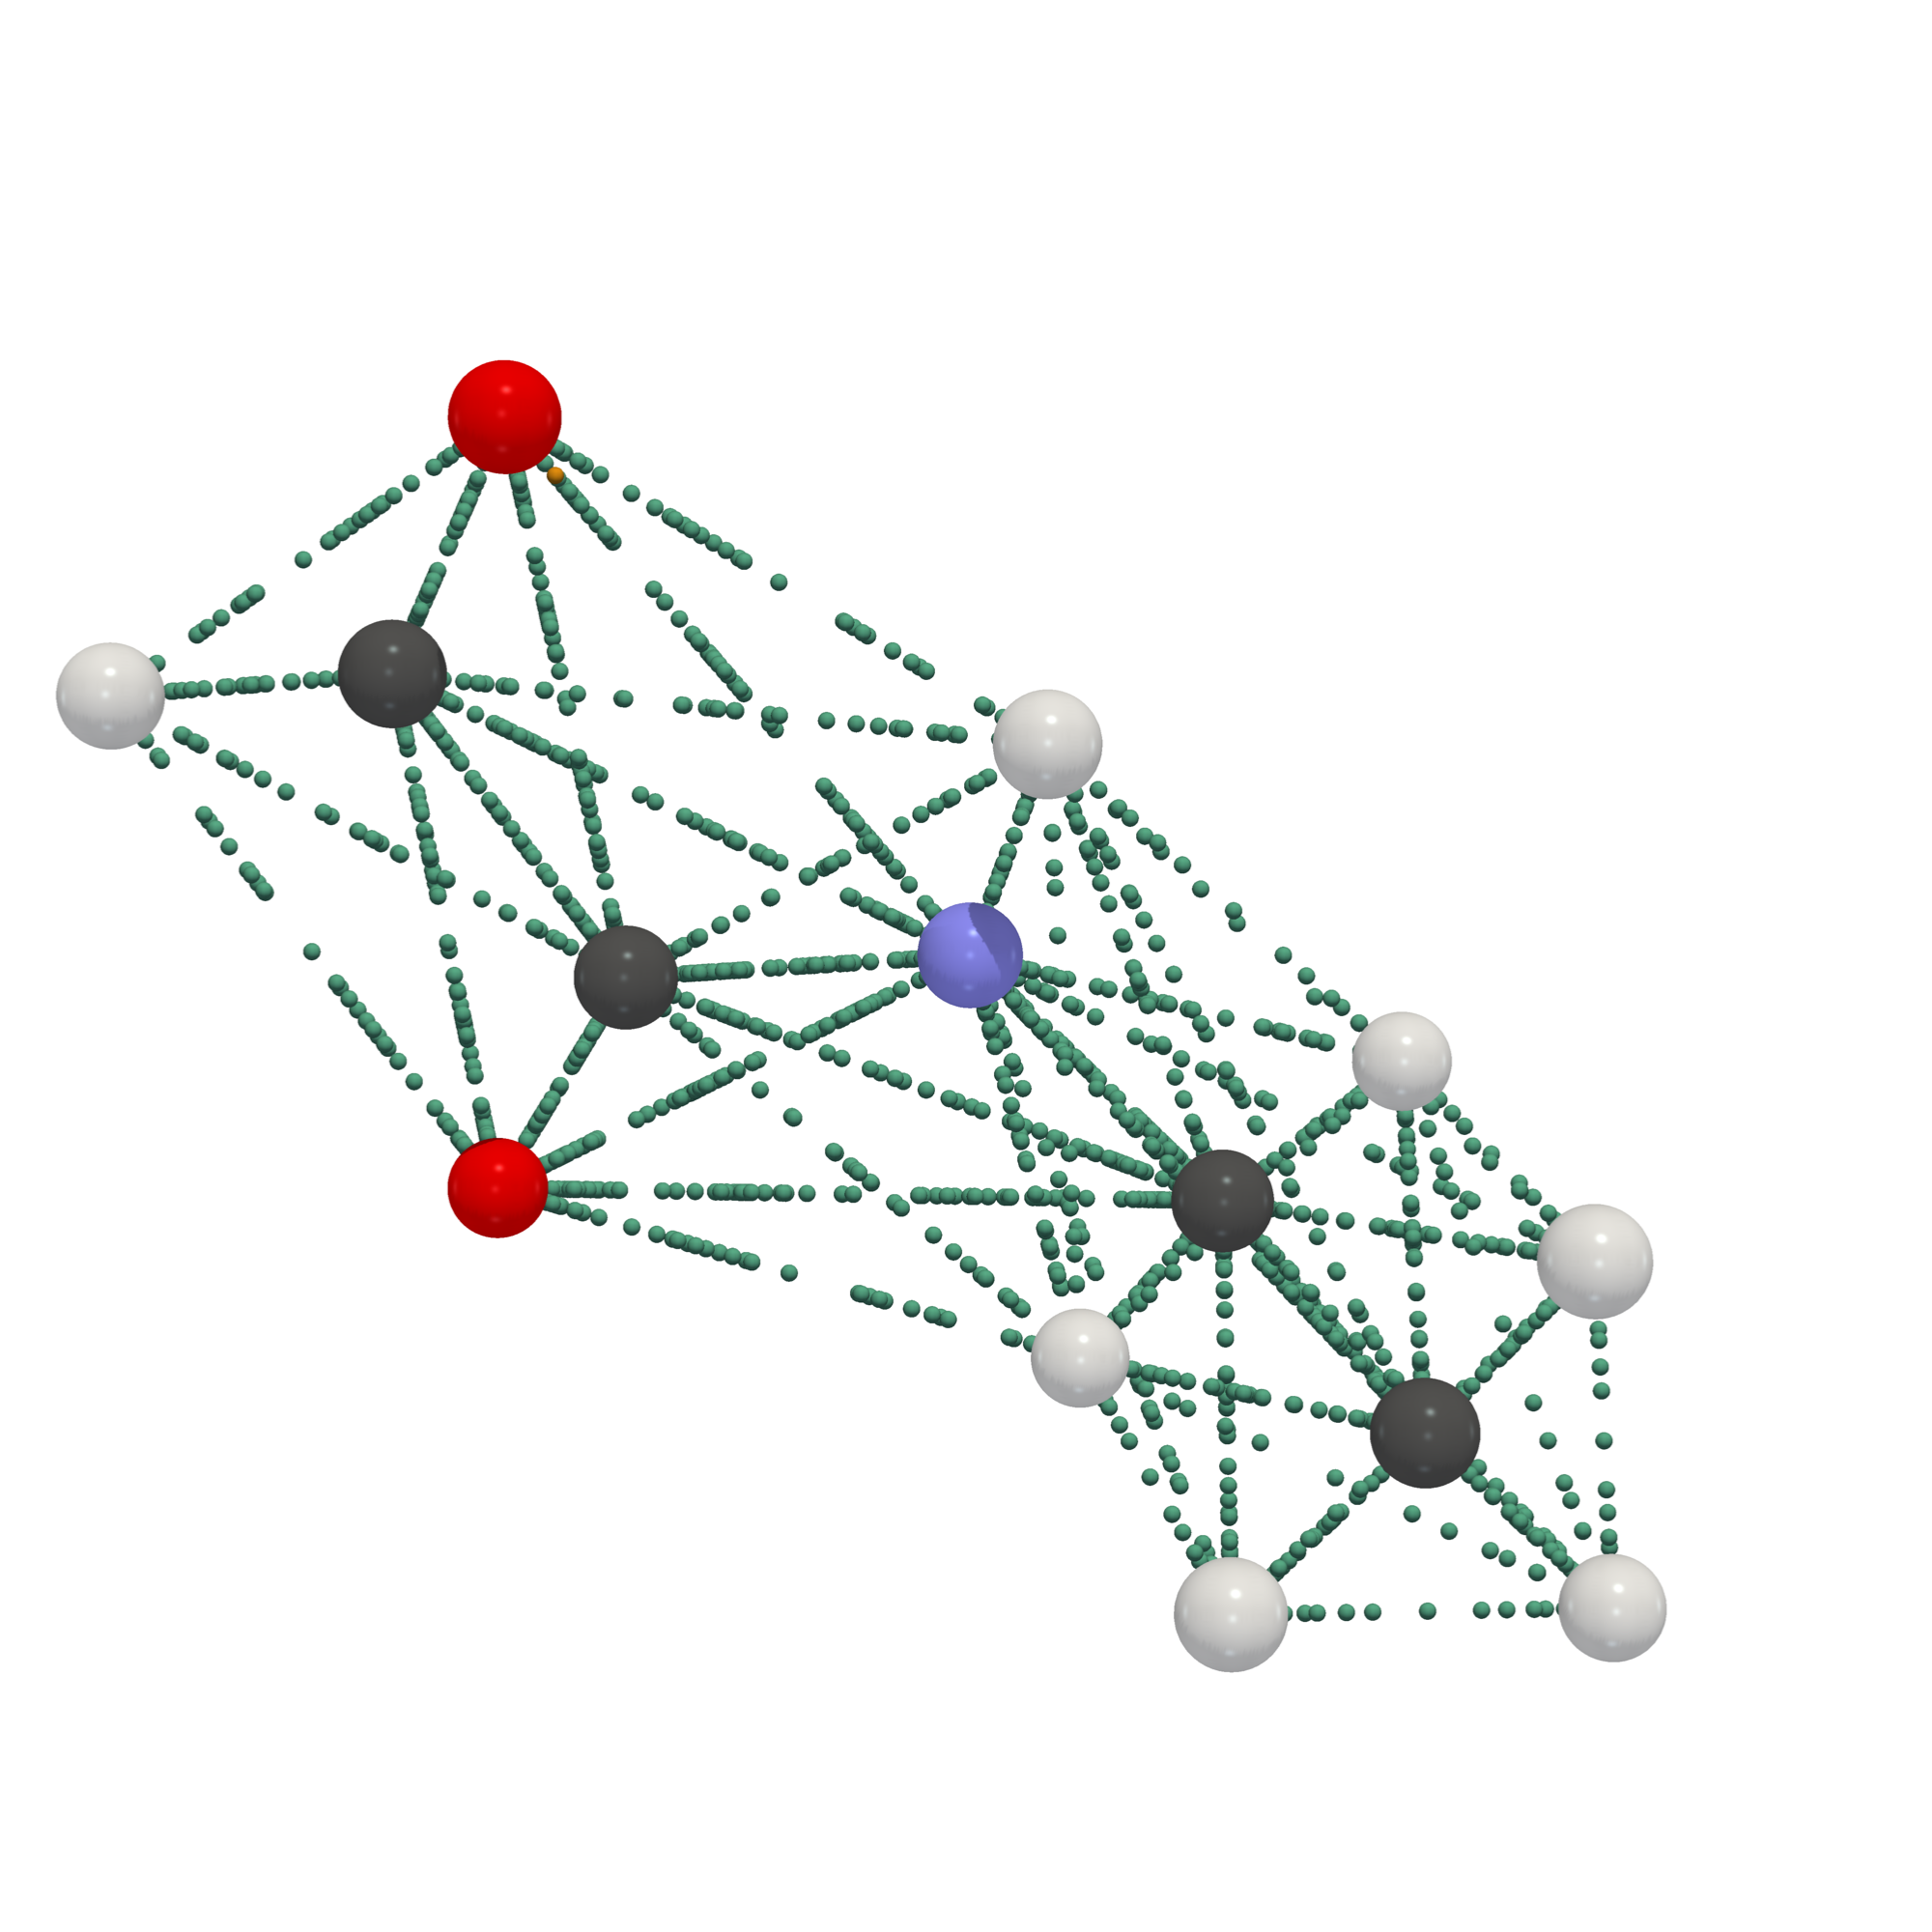

In [17]:
# Alternative: Create an isosurface for even smoother rendering
def create_smooth_isosurface(gaussian_grid, gaussian_values, isosurface_quantile=0.3):
    """
    Create a smooth isosurface instead of volume rendering for smoother appearance.
    """
    # Find appropriate isosurface value
    threshold = find_isosurface_value(np.abs(gaussian_values), isosurface_quantile, p=1)
    
    # Create isosurface for positive values
    pos_surface = gaussian_grid.contour([threshold], scalars="gaussian_product")
    
    # Create isosurface for negative values if they exist
    neg_mask = gaussian_values < 0
    if neg_mask.sum() > 0:
        neg_surface = gaussian_grid.contour([-threshold], scalars="gaussian_product")
        return pos_surface, neg_surface, threshold
    else:
        return pos_surface, None, threshold

# Create isosurface version
pos_surface, neg_surface, threshold = create_smooth_isosurface(gaussian_grid, gaussian_values, 0.3)

# Plot with isosurfaces for comparison
plotter_iso = pv.Plotter(notebook=True, window_size=window_size)
plotter_iso = plot_mol_and_connections(plotter_iso)

# Add positive isosurface (blue)
if pos_surface.n_cells > 0:
    plotter_iso.add_mesh(
        pos_surface, 
        color='#4287f5', 
        opacity=0.6, 
        smooth_shading=True,
        specular=0.3,
        ambient=0.2,
        diffuse=0.8
    )

# Add negative isosurface (red) if it exists
if neg_surface is not None and neg_surface.n_cells > 0:
    plotter_iso.add_mesh(
        neg_surface, 
        color='#f54242', 
        opacity=0.6, 
        smooth_shading=True,
        specular=0.3,
        ambient=0.2,
        diffuse=0.8
    )

plotter_iso.camera_position = 'iso'
plotter_iso.camera.zoom(1.2)
plotter_iso.enable_anti_aliasing('msaa')

print(f"Isosurface threshold: {threshold:.6f}")
print(f"Positive surface cells: {pos_surface.n_cells if pos_surface.n_cells > 0 else 'None'}")
print(f"Negative surface cells: {neg_surface.n_cells if neg_surface is not None and neg_surface.n_cells > 0 else 'None'}")

plotter_iso.show()
_ = plotter_iso.screenshot('bonds_isosurface_smooth.png', transparent_background=True, window_size=window_size)